# $\color{gray}{\text{7.0 Lecture Note Preparation}}$

*已有 Jupyter Notebook 经验的同学可跳过本节* 

## Miniconda 

[Miniconda](https://www.anaconda.com/download) 是一个轻量级的 Python 发行版. 安装时勾选 `Add Miniconda to my PATH environment variable`. 

## VS Code

`ctrl` + `,` 搜索 `terminal.integrated.profiles.windows`, 点击 `Edit in settings.json`, 添加如下配置:

```json
"terminal.integrated.profiles.windows": {
    // ... 其余终端配置
        "Conda": {
        "path": "cmd.exe",
        "args": [
            "/K",
            "{$你的miniconda3路径}\\Scripts\\activate.bat",
            "{$你的miniconda3路径}"
        ],
        "icon": "python"
        }
    },
    "terminal.integrated.defaultProfile.windows": "Conda",
```

即可更换 VS Code 默认终端为 conda. 

## 环境配置

```bash
conda update -n base conda -y
conda config --set solver libmamba
conda config --add channels https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/main/
conda config --add channels https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/free/
conda config --add channels https://mirrors.tuna.tsinghua.edu.cn/anaconda/cloud/conda-forge/
conda create -n net-model python=3.10 -y
conda activate net-model
conda install numpy matplotlib scipy ipykernel ipywidgets jupyter -y
```

## 阅读

- VS Code 右上角选择内核 `net-model(Python 3.10)`
- 或运行 `jupyter notebook --no-browser --port=8888`
  - 在[浏览器](http://127.0.0.1:8888)阅读
  - [点击](http://127.0.0.1:8888) 并在右上角点击选择 `Trusted`, 并启用插件 `Jupyter Notebook Renderers`, 从而在 VS Code 阅读

# $\color{gray}{\text{7.4 Recurrent Networks}}$

更丰富, 更难分析的动力学

## 7.4.1 Linear Recurrent Networks(线性循环网络)


> Recall: $\begin{aligned}\tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\vec{h} + \mathbb{M}\vec{v})\end{aligned}$

激活函数 $F(x) = x$. 这会引入不真实的负 $\vec{v}$. 动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{h} + \mathbb{M}\vec{v}\end{aligned}$

$\mathbb{M}$ 为对称阵时有分析解. 本征方程 $\begin{aligned}\mathbb{M}\cdot\vec{e}_{\mu} = \lambda_{\mu}\vec{e}_{\mu},\quad \mu = \{1,2\cdots,N_{v}\}\end{aligned}$, 或分量形式 $\begin{aligned}\sum_{j=1}^{N_{v}}M_{ij}e_{\mu}^{j} = \lambda_{\mu} e_{\mu}^{j}\end{aligned}$

$\{\vec{e}_{\mu}\}$ 构成正交基 ($\vec{e}_{\mu}\vec{e}_{\nu} = \delta_{\mu\nu}$), 以该基表达 $\begin{aligned}\vec{v}(t) = \sum_{\mu=1}^{N_{v}}c_{\mu}(t)\vec{e}_{\mu}\end{aligned}$. 代入动力学: 

$$
\begin{aligned}
\tau_{r}\sum_{\mu=1}^{N_{v}}\frac{\mathrm{d}c_{\mu}}{\mathrm{d}t}\vec{e}_{\mu} &= - \sum_{\mu=1}^{N_{v}}(1-\lambda_{\mu})c_{\mu}(t) \vec{e}_{\mu} + \vec{h}\\
(\cdots)\cdot\vec{e}_{\nu}\Rightarrow\tau_{r}\frac{\mathrm{d}c_{\nu}}{\mathrm{d}t} &= - (1-\lambda_{\nu})c_{\nu} + \vec{h}\cdot\vec{e}_{\nu}\\
c_{\nu}(t) &= \frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\left[1 - \exp{\left(-\frac{t(1-\lambda_{\nu})}{\tau_{r}}\right)}\right] + c_{\nu}(0)\exp{\left[-\frac{t(1-\lambda_{\nu})}{\tau_{r}}\right]},\quad c_{\nu}(0) = \vec{v}(0)\cdot\vec{e}_{\nu}
\end{aligned}
$$

- $\lambda_{\nu} > 1$: $c_{\nu}\to\infty$, 网络不稳定
- $\lambda_{\nu} < 1$: $\begin{aligned}c_{\nu}\to\frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\end{aligned}$. $\vec{h}\cdot\vec{e}_{\nu}$ 是 $\vec{h}$ 在 $\vec{e}_{\nu}$ 方向上的投影
  - $\lambda_{\nu}\in(0,1)$: 稳态是投影被放大了 $\begin{aligned}\frac{1}{1-\lambda_{\nu}}\end{aligned}$

$$
\vec{v}_{\infty} = \sum_{\nu=1}^{N_{v}}\frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\vec{e}_{\nu}
$$

### 7.4.1.1 Selective Amplification(选择性放大)

- 若 $\begin{aligned}\lambda_{1} = \lim_{\epsilon\to 0}1 - \epsilon\gg \lambda_{i} (i\neq 1)\end{aligned}$, 则 $|c_{1}|\gg |c_{i}|(i\neq 1)$, 则稳态 $\begin{aligned}\vec{v}_{\infty}\approx \frac{(\vec{h}\cdot\vec{e}_{1})}{1-\lambda_{1}}\vec{e}_{1}\end{aligned}$. 

  - 简并(degeneracy): 若 $\begin{aligned}\lambda_{1} = \lambda_{2} = \lim_{\epsilon\to 0}1 - \epsilon\gg \lambda_{i} (i\neq 1)\end{aligned}$, 稳态 $\begin{aligned}\vec{v}_{\infty}\approx \frac{(\vec{h}\cdot\vec{e}_{1})\vec{e}_{1} + (\vec{h}\cdot\vec{e}_{2})\vec{e}_{2}}{1-\lambda_{1}}\end{aligned}$. 

- 结论: 输入被编码至 $\lambda_{i}\sim 1$ 的子空间(维数取决于简并度). 

### 7.4.1.2 Input Integration(输入积分)

- 若 $\lambda_{1} = 1 > \lambda_{i} (i\neq 1)$, 动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}c_{1}}{\mathrm{d}t} = \vec{h}\cdot\vec{e}_{1}\end{aligned}$, 解 $\begin{aligned}c_{1}(t) = c_{1}(0) + \frac{1}{\tau_{r}}\int_{0}^{t}\mathrm{d}t^{\prime}\vec{h}(t^{\prime})\cdot\vec{e}_{1}\end{aligned}$

  - $\vec{h}(t) = \vec{h}(0)$, 则 $c_{1}\propto t\to\infty$. 
  - $\begin{aligned}\vec{h}(t) = \begin{cases} g(t)\neq 0, t\in (0,t_{0})\\ 0, t\in(t_{0},\infty) \end{cases}\end{aligned}$. 
    - $\nu\neq 1$: $\lambda_{\nu} < 1$, $c_{\nu}\to 0$. 
    - 设 $c_{1}(0)=0$, 动力学: $\begin{aligned}\vec{v}(t)\approx \frac{\vec{e}_{1}}{\tau_{r}}\int_{0}^{t}\mathrm{d}t^{\prime}\vec{h}(t^{\prime})\cdot\vec{e}_{1}\end{aligned}$
    - 即使撤去输入 $\vec{h}(t) = 0\,[t\in(t_{0},\infty)]$, 网络表现出持续活动(sustained activity), 即 "记忆". 
- [Example] 脊椎动物眼球位置维持
  
    <img src="https://files.seeusercontent.com/2026/05/04/X2nw/20260504160234935.png" width="50%">
  
  - integrator neurons(内侧前庭核, 舌下前核): 放电率近似正比于眼球方向角
  - burst neurons: 图中出现两次扫视(saccadic), 分别驱动眼球相反方向移动
  - integrator neurons 接收 burst neurons(ON/OFF) 信号并对其积分, 无输入时保持恒定持续活动(persistent activity)
  - 结论: 线性循环网络在 $\mathbb{M}$ 主特征值为 1 时表现出积分能力

### 7.4.1.3 Continuous Linear Recurrent Networks(连续线性循环网络)

recall: 连续形式网络动力学 $\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = - v(\theta) + F\left[\rho_{\theta}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}W(\theta,\theta^{\prime})u(\theta^{\prime}) + M(\theta,\theta^{\prime})v(\theta^{\prime})\right]\end{aligned}$, 线性 $F(x) = x$ 得到

$\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = - v(\theta) + h(\theta) + \rho_{\theta}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}M(\theta-\theta^{\prime})v(\theta^{\prime})\end{aligned}$

- $h$, $M$, $v$ 均为 $T=2\pi$ 的周期函数
- $M$ 通过 $\theta-\theta^{\prime}$ 具有平移/旋转不变性, 并且设为偶函数 $M(\theta-\theta^{\prime}) = M(\theta^{\prime}-\theta)$

类比于离散形式的本征方程 $\begin{aligned}\sum_{j=1}^{N}M_{ij}e_{\mu}^{j} = \lambda_{\mu}e_{\mu}^{i}\end{aligned}$, 应用替换 $\begin{aligned}e_{\mu}^{i}\to e_{\mu}(\theta),\,\sum_{j=1}^{N_{v}}M_{ij}v_{j}\to\int_{-\pi}^{\pi}\rho_{\theta}\mathrm{d}\theta^{\prime}M(\theta,\theta^{\prime})v(\theta^{\prime})\end{aligned}$, 连续形式本征方程为

$$
\rho_{\theta} \int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\,M(\theta-\theta^{\prime})e_{\mu}(\theta^{\prime}) = \lambda_{\mu}e_{\mu}(\theta)
$$

- 平移/旋转不变性($\theta-\theta^{\prime}$): 本征函数为复指数/正余弦函数
  - 猜测解 $e_{\mu}(\theta) = e^{i\mu\theta}\,(\mu\in\mathbb{Z})$, 代入左边有 $\begin{aligned}\rho\int_{-\pi}^{\pi}M(\theta-\theta^{\prime})e^{i\mu\theta^{\prime}}\mathrm{d}\theta^{\prime} = \rho\int_{-\pi}^{\pi}M(z)e^{i\mu(\theta-z)}\mathrm{d}z = e^{i\mu\theta}\left(\rho\int_{-\pi}^{\pi}M(z)e^{-i\mu z}\mathrm{d}z\right) = e^{i\mu\theta}\lambda_{\mu}\end{aligned}$. 
- 归一化要求: $\begin{aligned}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\,\rho_{\theta}[e_{\mu}(\theta^{\prime})]^{2} = 1\end{aligned}$, 解得 $\begin{aligned}e_{0}(\theta) = \frac{1}{\sqrt{2\pi\rho_{\theta}}}\end{aligned}$, $\begin{aligned}e_{\mu}(\theta) = \frac{\sin{(\mu\theta)}}{\sqrt{\pi\rho_{\theta}}}\end{aligned}$ 和 $\begin{aligned}e_{\mu}(\theta) = \frac{\cos{(\mu\theta)}}{\sqrt{\pi\rho_{\theta}}},\,(\mu\neq 0)\end{aligned}$
- 特征值 $\lambda_{\mu}$ 是 $M$ 的 Fourier 变换: $\begin{aligned}\lambda_{\mu} = \rho_{\theta}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}M(\theta^{\prime})\cos{(\mu\theta^{\prime})}\end{aligned}$
- 根据稳态公式 $\begin{aligned}\vec{v}_{\infty} = \sum_{\nu=1}^{N_{\nu}}\frac{\vec{h}\cdot\vec{e}_{\nu}}{1-\lambda_{\nu}}\vec{e}_{\nu}\end{aligned}$, 类比得到

    $$
    v_{\infty}(\theta) = \frac{1}{1-\lambda_{0}}\int_{-\pi}^{\pi}\frac{\mathrm{d}\theta^{\prime}}{2\pi}h(\theta^{\prime}) 
    + \sum_{\mu=1}^{\infty}\frac{\cos{(\mu\theta)}}{1-\lambda_{\mu}}\int_{-\pi}^{\pi}\frac{\mathrm{d}\theta^{\prime}}{\pi}h(\theta^{\prime})\cos{(\mu\theta^{\prime})} 
    + \sum_{\mu=1}^{\infty}\frac{\sin{(\mu\theta)}}{1-\lambda_{\mu}}\int_{-\pi}^{\pi}\frac{\mathrm{d}\theta^{\prime}}{\pi}h(\theta^{\prime})\sin{(\mu\theta^{\prime})} 
    $$

  - 某 $\lambda_{\mu}\approx 1$ 时, $\begin{aligned}\frac{1}{1-\lambda_{\mu}}\end{aligned}$ 会使该项的贡献无限放大, 其余成分则被抑制; 无论 $h(\theta)$ 成分如何, $\mu=1$ 都会使最终网络活动呈现余弦调制曲线. 
  - [Example] 设定 $\begin{aligned}M(\theta-\theta^{\prime}) = \frac{\lambda_{1}}{\pi\rho_{\theta}}\cos{(\theta-\theta^{\prime})},\,\lambda_{1} = 0.9\end{aligned}$

     <img src="https://files.seeusercontent.com/2026/05/04/3Sfn/20260504195548236.png" width="50%">

    - $\mu=1$ 成分被放大了 $\begin{aligned}\frac{1}{1-\lambda_{1}} = 10\end{aligned}$ 倍, 其余则是 $\begin{aligned}\frac{1}{1-0} = 1\end{aligned}$ 倍. 这相当于信噪比的提升. 

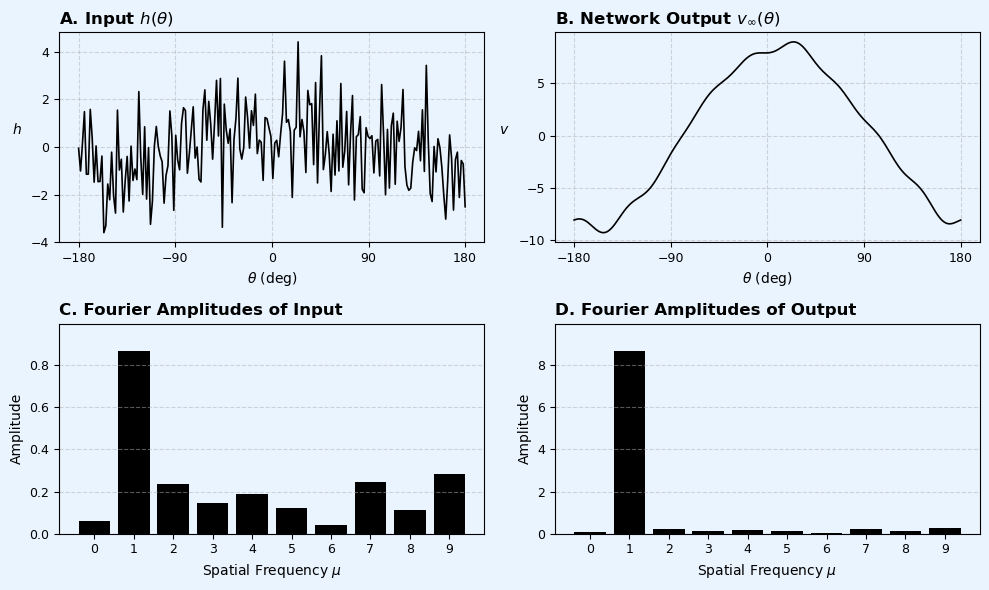

In [2]:
%run tutorials/7.8.py

## 7.4.2 Nonlinear Recurrent Networks(非线性循环网络)

- 循环权重: 仍为 $\begin{aligned}M(\theta-\theta^{\prime}) = \frac{\lambda_{1}}{\pi\rho_{\theta}}\cos{(\theta-\theta^{\prime})}\end{aligned}$ 
- 激活函数: 阈值线性函数: $\vec{F}(\vec{h} + \mathbb{M}\vec{r}) = [\vec{h} + \mathbb{M}\vec{r} - \vec{\gamma}]_{+} = \max{(\vec{0}, \vec{h} + \mathbb{M}\vec{r} - \vec{\gamma})}$. 
  - 阈值 $\vec{\gamma}$ 通常选为 $\vec{0}$
- (连续)动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = - v(\theta) + \left[h(\theta) + \frac{\lambda_{1}}{\pi}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\cos{(\theta-\theta^{\prime})}v(\theta^{\prime})\right]_{+}\end{aligned}$

### 7.4.2.1 Nonlinear Amplification(非线性放大)

引入阈值函数后, 不需要线性网络的严格条件($\lambda < 1$), 也能消除噪声

<img src="https://files.seeusercontent.com/2026/05/04/7dwV/20260504203418562.png" width="55%">


- $\lambda_{1} = 1.9$: 具有非 0 响应的神经元相对更少(因为阈值)
- 整流 $[\cdot]_{+}$ 的直流和倍频效应: $\mu=0,1,2,4,6,8\cdots$ 都被放大了. 因为 $[\cos{(\theta)}]_{+}$ 不再是纯粹的 $\mu=1$ 波, 将会泄露出其余频率的分量:
  - $\mu=0$(DC 直流): $\begin{aligned}a_{0} = \frac{1}{2\pi}\int_{-\pi/2}^{\pi/2}\cos{(\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{1}{\pi}\end{aligned}$
  - $\mu=1$(Fundamental 基频): $\begin{aligned}a_{1} = \frac{1}{\pi}\int_{-\pi/2}^{\pi/2}\cos^{2}{(\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{1}{2}\end{aligned}$
  - $\mu=2$(Second Harmonic 二次谐波): $\begin{aligned}a_{2} = \frac{1}{\pi}\int_{-\pi/2}^{\pi/2}\cos{(\theta^{\prime})}\cos{(2\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{2}{3\pi}\end{aligned}$
- 更一般的数学推导. 
  - 设 $v(\theta) = [A\cos{(\theta)}- T]_{+}$, 则存在临界 $\theta_{c}$ 使得 $\begin{aligned}\cos{(\theta_{c})} = \frac{T}{A}\end{aligned}$. 即 $\theta\in (-\theta_{c},\theta_{c})$ 神经元放电. 
  - Fourier 级数 $\begin{aligned}v(\theta) = a_{0} + \sum_{\mu=1}^{\infty}a_{\mu}\cos{(\mu\theta)}\end{aligned}$ 展开: $\begin{aligned}a_{\mu} = \frac{1}{\pi}\int_{-\theta_{c}}^{\theta_{c}}[A\cos{(\theta^{\prime})}-T]\cos{(\mu\theta^{\prime})}\mathrm{d}\theta^{\prime} = \frac{A}{\pi}\int_{-\theta_{c}}^{\theta_{c}}[\cos{(\theta^{\prime})}-\cos{\theta_{c}}]\cos{(\mu\theta^{\prime})}\mathrm{d}\theta^{\prime}\end{aligned}$
  - 和差化积解得 $\begin{aligned}a_{\mu} = \frac{A}{\pi}\left\{\frac{\sin{[(\mu-1)\theta_{c}]}}{\mu(\mu-1)} - \frac{\sin{[(\mu+1)\theta_{c}]}}{\mu(\mu+1)}\right\}\end{aligned}$. 
    - $\mu=2k-1$: 振幅为 0
    - $\begin{aligned}\mu=2k:\, a_{2k} = \frac{A}{\pi}\frac{2(-1)^{k+1}}{4k^{2}-1}\end{aligned}$, 从而解释偶次谐波的放大逐渐减少. 

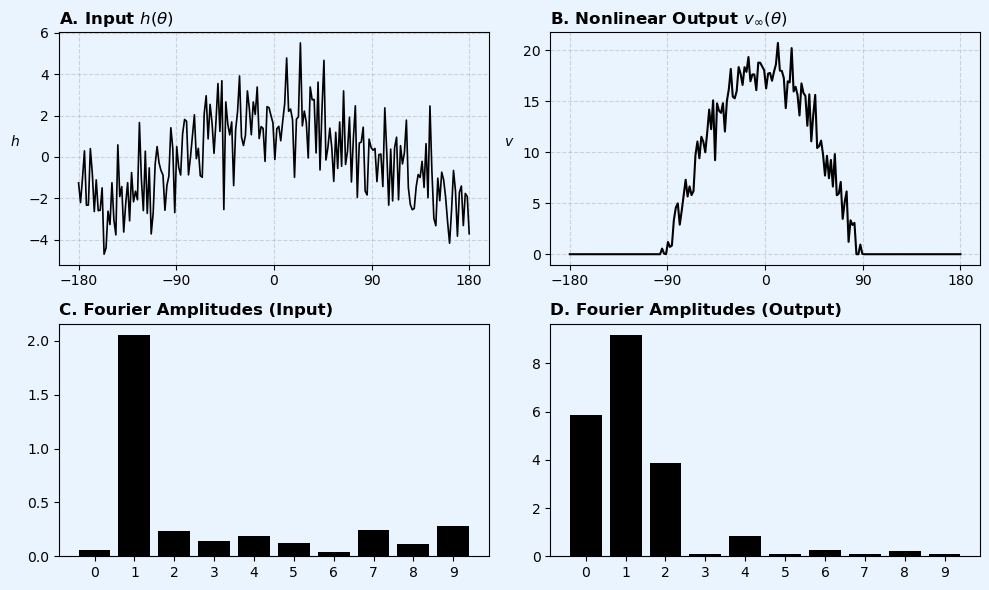

In [3]:
%run tutorials/7.9.py

### 7.4.2.2 Recurrent Model 1: **Simple Cells** in Primary Visual Cortex

- recall: 
  - 前馈模型: 初级视觉皮层的感受野是 Lateral Geniculate Nucleus(LGN) 的输入总和. ON 和 OFF 交替排列. 
  - 方位调制(orientation tuning) 难以和大脑皮层的解剖结构吻合
  - 存在大量的皮层内连接, 暗示着循环网络的作用
- Ben-Yishai, Bar-Or & Sompolinsky: 循环网络解释方位调制曲线. 动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}v(\theta)}{\mathrm{d}t} = -v(\theta) + \left[h(\theta) + \int_{-\pi/2}^{\pi/2}\frac{\mathrm{d}\theta^{\prime}}{\pi}[-\lambda_{0} + \lambda_{1}\cos{(2(\theta-\theta^{\prime}))}]v(\theta^{\prime})\right]_{+}\end{aligned}$
  - 引入了全局抑制作用 $-\lambda_{0}$
  - 方位角定义为 $\begin{aligned}\theta^{\prime}\in\left[-\frac{\pi}{2},\frac{\pi}{2}\right]\end{aligned}$ 而非 $[-\pi,\pi]$. 因此额外有一个 2 的因子.
  - 偏好角 $\Theta = 0$ 的输入:  $h(\theta) = Ac[1 - \epsilon + \epsilon\cos{(2\theta)}]$
    - $v(\theta) = v(\theta-\Theta)$, 且 $v(-\theta) = v(\theta)$
    - $A$: 整体幅值
    - $c$: 图像对比度(image contrast)
    - $\epsilon$: 调制强度. 研究中将令 $\epsilon\to 0$, 使强方向调制只可能来源于循环网络作用
      - $\epsilon = 0$: 无调制
      - $\epsilon = 0.5$: 和正向输入一致的最大调制(波谷 $1-2\epsilon = 0$)
  - [Example]

    <img src="https://files.seeusercontent.com/2026/05/04/pyB4/20260504214633248.png" width="70%">

    - A: 前馈输入 $c = [80, 40, 20, 10]\%$, 弱输入调制
    - B: 循环网络 $c = [80, 40, 20, 10]\%$,  $\lambda_{0} = 7.3$, $\lambda_{1} = 11$, $A = 40\,\mathrm{Hz}$, $\epsilon=0.1$, 强输出调制
    - C: 调制曲线

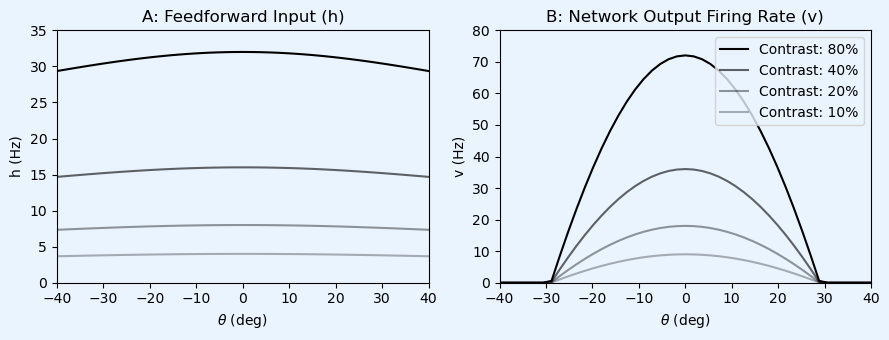

In [4]:
%run tutorials/7.10.py

### 7.4.2.3 Recurrent Model 2: **Complex Cells** in Primary Visual Cortex

循环网络可以放大选择性响应从而增强选择性, 也可以放大非选择性响应从而减弱选择性. 

recall: 复杂细胞没有 ON/OFF, 而是对特定方位/空间频率光栅做出响应, 而对光栅的位置(空间相位)不敏感

Chance, Nelson & Abbott: 循环网络解释简单细胞响应生成复杂细胞响应. 

- Setup: 
  - $\phi$: 简单细胞偏好的空间相位
  - $h(\phi)$: 模型的前馈输入
  - $\begin{aligned} M(\phi-\phi^{\prime}) = \frac{\lambda_{1}}{2\pi\rho_{\phi}} \end{aligned}$: **均匀** 循环权重
- 动力学: $\begin{aligned} \tau_{r}\frac{\mathrm{d}v(\phi)}{\mathrm{d}t} = - v(\phi) + \left[h(\phi) + \int_{-\pi}^{\pi} \rho_{\phi}\mathrm{d}\phi^{\prime}\,\frac{\lambda_{1}}{2\pi\rho_{\phi}}v(\phi^{\prime}) \right]_{+} \end{aligned}$
  - $\lambda_{1} = 0$: 无循环连接, $v(\phi) = h(\phi)$, 等效于简单细胞 $\phi$
  - $\lambda_{1} \sim 1$: 类似于复杂细胞
- [Example]

    <img src="https://files.seeusercontent.com/2026/05/05/Rec2/20260505155625321.png" width="70%">

  - A: 强调制输入 $\lambda_{1} = 0.95$
  - B: 弱调制输出 (相位不敏感)
  - 并非完全移除了调制差值, 而是通过增强广域的响应使得相对差值变小. 
    - 稳态方程 $\begin{aligned}v_{\infty}(\phi) = h(\phi) + \frac{\lambda_{1}}{2\pi}\int_{-\pi}^{\pi} v(\phi^{\prime})\mathrm{d}\phi^{\prime}\end{aligned}$. 
    - 平均放电率 $\begin{aligned}\bar{v} = \frac{1}{2\pi}\int_{-\pi}^{\pi}v(\phi^{\prime})\mathrm{d}\phi^{\prime}\end{aligned}$, 平均输入 $\begin{aligned}\bar{h} = \frac{1}{2\pi}\int_{-\pi}^{\pi}h(\phi^{\prime})\mathrm{d}\phi^{\prime}\end{aligned}$
    - 稳态方程: $v(\phi) = h(\phi) + \lambda_{1}\bar{v}$. 同时 $\begin{aligned}\int_{-\pi}^{\pi}\mathrm{d}\phi^{\prime}\end{aligned}$, 得到 $\bar{v} = \bar{h} + \lambda_{1}\bar{v}$, 即 $\begin{aligned}\bar{v} = \frac{\bar{h}}{1 - \lambda_{1}}\end{aligned}$
    - $\begin{aligned}v(\phi) = h(\phi) + \frac{\lambda_{1}}{1-\lambda_{1}}\bar{h}\end{aligned}$
    - 绝对差值不变: $\Delta v = \Delta h$
    - 相对差值减小: $\begin{aligned}\frac{\Delta v}{\bar{v}} = \frac{\Delta h}{\bar{h}}\frac{1}{1-\lambda_{1}} = (1-\lambda_{1})\frac{\Delta h}{\bar{h}}\ll \frac{\Delta h}{\bar{h}}\end{aligned}$

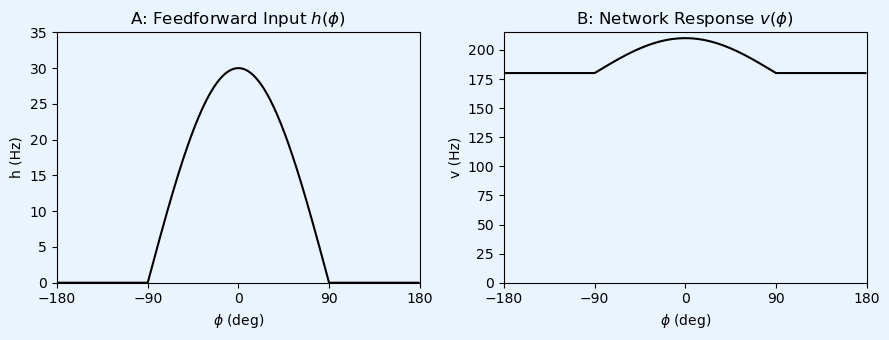

In [5]:
%run tutorials/7.11.py

### 7.4.2.4 Winner-Takes-All Input Selection("赢家通吃" 输入选择性)

- 线性网络: 响应线性叠加
- 非线性网络: 多个峰输入, 根据网络选择其中一个峰的响应作为主要输出
  - 不一定幅值越高越好, 需要根据网络权重来确定
  - [Example]

    <img src="https://files.seeusercontent.com/2026/05/05/7xoQ/20260505163203254.png" width="70%">
    
    - Setup: 
    - A: 双峰输入 $h(\phi)$
    - B: 单峰输出 $v(\phi)$

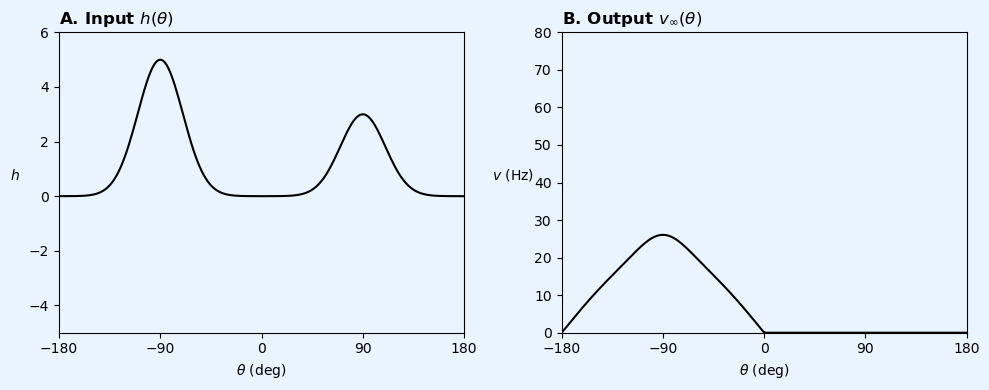

In [6]:
%run tutorials/7.12.py

### 7.4.2.5 Gain Modulation(增益调节)

recall: 后顶叶神经元(posterior parietal neurons) 依赖于 $s+g$. 

<img src="https://files.seeusercontent.com/2026/04/30/0gMw/20260430150704898.png" width="50%">

- $s$: 视网膜的偏好刺激位置, 也用 $\theta$ 表示
- $g$: 注视方向

<img src="https://files.seeusercontent.com/2026/04/30/aGz0/20260430164409174.png" width="50%">

---

- 动力学: $\begin{aligned}\tau\frac{\mathrm{d}v}{\mathrm{d}t} = - v + \left[h(\theta) + \int_{-\pi}^{\pi}W(\theta,\theta^{\prime})v(\theta^{\prime})\mathrm{d}\theta^{\prime}\right]_{+}\end{aligned}$
  - 输入 $\begin{aligned}h(\theta) = A e^{-\frac{\theta^{2}}{2\sigma^{2}}} + c\end{aligned}$
  - 循环权重 $\begin{aligned}W(\theta,\theta^{\prime}) = \frac{1}{2\pi}[-J_{0} + J_{1}\cos{(\theta - \theta^{\prime})}]\end{aligned}$

<img src="https://files.seeusercontent.com/2026/05/05/o7Xr/20260505164847499.png" width="50%">

- A: 加上各常数项后的输入 $h(\theta)$. 不同常数代表不同的注视方向 $g$. 
- B: 增益调节后的输出 $v(\theta)$. 
  - 峰曲线被成比例地放大了, 绝对位置没有变化

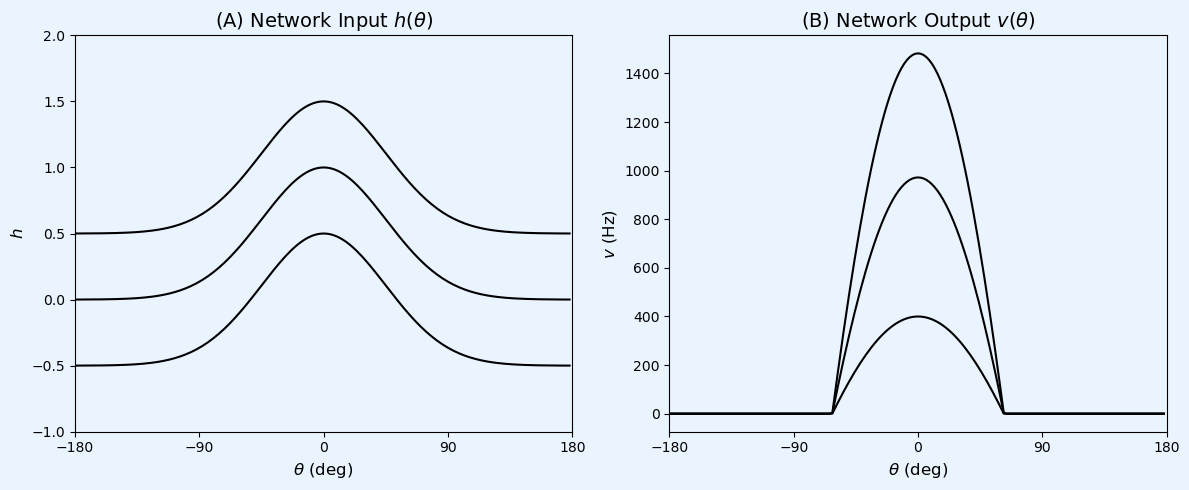

In [7]:
%run tutorials/7.13.py

### 7.4.2.6 Sustained Activity(持续活动)

非线性循环网络的循环连接可以产生独立于输入的群体活动. 

- 线性网络 $\begin{aligned} \tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{h} + \mathbb{M}\vec{v} = (\mathbb{M}-\mathbb{I})\vec{v} + \vec{h}\end{aligned}$
  - 具有 $\lambda_{1} = 1$ 的本征矢 $\vec{e}_{1}$. 因此 $\vec{v} = c\vec{e}_{1}\,(\forall c)$ 都是稳态解 (0-mode). 线性网络可记忆 $c$ 值
- 非线性网络
  - 无调制输入时稳态是 $\theta-\Theta$ 的函数(均匀输入带来旋转不变性). 峰值位置 $\Theta$ 相当于被保存. 

- [Example]

    <img src="https://files.seeusercontent.com/2026/05/05/3xmT/20260505192801179.png" width="50%">
    
  - A, C: 输入 $\begin{aligned}\vec{h}(t) = \begin{cases} g(t)\neq 0, t\in (0,t_{0})\\ \mathrm{const}., t\in(t_{0},\infty) \end{cases}\end{aligned}$.
  - B: 对 A 输入的响应
  - D: 在 A 输入撤去转为 C 输入后, 网络的响应
    - 即使表现出了幅值的衰弱, 但是 $\Theta$ 被保留下来
    - *由于稳态旋转不变性, 因此 $\Theta$ 会因为噪音出现漂移现象. 

- 生理学基础
  - 大鼠: 头朝向(head-direction system)
  - 前额叶皮层(prefrontal cortex): 工作记忆任务

> **省流: $\begin{aligned}D^{\prime} \propto \frac{D}{N}\end{aligned}$, 故网络越大越抗噪声.** 
> 
> 1. 动力学: $\begin{aligned} \tau\frac{\partial r(\theta, t)}{\partial t} = - r(\theta, t) + f\left(\int_{-\pi}^{\pi} W(\theta-\theta^{\prime})r(\theta^{\prime}, t)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right)\end{aligned}$
> 
>     无调制输入(仅 $I_{\mathrm{bg}}$): 稳态解 $\begin{aligned}\left(\frac{\mathrm{d}}{\mathrm{d}t}=0\right)\end{aligned}$ : $\begin{aligned}r_{0}(\theta-\Theta) = f(h_{0}(\theta)) = f\left(\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})r_{0}(\theta^{\prime}-\Theta)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right)\end{aligned}$. 
> 
>     引入微扰 $\delta r(\theta, t)$, 则动力学 $\begin{aligned}\tau\frac{\partial (r_{0}+\delta r)}{\partial t} =  - (r_{0} + \delta r) + f(h_{0} + \delta h)=  - (r_{0} + \delta r) + f\left(\int_{-\pi}^{\pi} W(\theta-\theta^{\prime})(r_{0}+\delta r)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right)\end{aligned}$
> 
>     注意 $\begin{aligned}\frac{\partial r_{0}}{\partial t} = 0\end{aligned}$. 采用 Taylor 展开 $f(h_{0}+\delta h)\approx f(h_{0}) + f^{\prime}(h_{0})\delta h$, 有 $\begin{aligned}\tau\frac{\partial \delta r}{\partial t} = -r_{0} - \delta r + f(h_{0}) + f^{\prime}(h_{0})\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})\delta r(\theta^{\prime})\mathrm{d}\theta^{\prime} \end{aligned}$
> 
>     注意 $-r_{0} + f(h_{0}) = 0$, 得到微扰动力学 $\begin{aligned}\tau\frac{\partial\delta r}{\partial t} = -\delta r + f^{\prime}(h_{0}(\theta))\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})\delta r(\theta^{\prime})\mathrm{d}\theta^{\prime} = \mathcal{L}\delta r\end{aligned}$
> 
>     网络动力学两边对 $\theta$ 求导: $\begin{aligned}r_{0}^{\prime}(\theta-\Theta) = f^{\prime}(h_{0}(\theta))\int_{-\pi}^{\pi}W(\theta-\theta^{\prime})r_{0}^{\prime}(\theta^{\prime}-\Theta)\mathrm{d}\theta^{\prime}\end{aligned}$. 注意 $\delta r = r_{0}^{\prime}$ 时, 有 $\mathcal{L}r_{0}^{\prime} = 0r_{0}^{\prime}$. 
>     
>     即 $r_{0}^{\prime}$ 是 $\mathcal{L}$ 的 0-mode(特征值为 0). 这代表着网络活动的平移不变性. 
> 
> 2. 引入噪声 $\langle\xi(\theta, t)\rangle = 0$, $\langle\xi(\theta, t)\xi(\theta^{\prime},t^{\prime})\rangle = 2D\delta(\theta-\theta^{\prime})\delta(t-t^{\prime})$. 
> 
>     动力学(Langevin): $\begin{aligned}\tau\frac{\partial r(\theta, t)}{\partial t} = -r(\theta, t) + f\left(\int_{-\pi}^{\pi} W(\theta-\theta^{\prime})r(\theta^{\prime}, t)\mathrm{d}\theta^{\prime} + I_{\mathrm{bg}}\right) + \xi(\theta, t)\end{aligned}$
> 
>     写作微扰形式 $r(\theta, t) = r_{0}(\theta-\Theta) + \delta r(\theta, t)$. 链式法则 $\begin{aligned}\frac{\partial r_{0}}{\partial t} = -r_{0}^{\prime}\dot{\Theta}\end{aligned}$, 代入动力学: $\begin{aligned}-\tau\dot{\Theta}r_{0}^{\prime}(\theta-\Theta) + \tau\frac{\partial\delta r}{\delta t} = \mathcal{L}\delta r + \xi(\theta, t)\end{aligned}$
> 
>     引入伴随算子 $\mathcal{L}^{\dagger}$, 及其 0-mode $\mathcal{L}^{\dagger}v_{0}^{*} = 0$. 微扰动力学同左乘 $v_{0}^{*}$ 并对 $\theta$ 积分, 且注意 $\begin{aligned}\int v_{0}^{*}(\mathcal{L}\delta r)\mathrm{d}\theta = \int (\mathcal{L}^{\dagger}v_{0}^{*})\delta r\mathrm{d}\theta = 0\end{aligned}$, 则得到 $\begin{aligned} -\tau\dot{\Theta}\int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime} = \int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime}-\Theta)\xi(\theta^{\prime}, t)\mathrm{d}\theta^{\prime} \end{aligned}$, 分离系数: 
> 
>     $$
>     \begin{equation*}
>     \tau\dot{\Theta} = - \frac{\begin{aligned}
>         \int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime})\xi(\theta^{\prime}, t)\mathrm{d}\theta^{\prime}
>     \end{aligned}}{\begin{aligned}
>         \int_{-\pi}^{\pi} v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime}
>     \end{aligned}} = - \frac{\langle v_{0}^{*},\xi\rangle}{\langle v_{0}^{*}, r_{0}^{\prime}\rangle}
>     \end{equation*}
>     $$
> 
> 3. 求解扩散系数. 
> 
>     $$
>     \begin{align*}
>     \langle \dot{\Theta}(t^{\prime})\dot{\Theta}(t^{\prime\prime})\rangle &= \frac{1}{\tau^{2}}\frac{\begin{aligned}
>         \int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime}\int_{-\pi}^{\pi}\mathrm{d}\theta^{\prime\prime}\, v_{0}^{*}(\theta^{\prime})v_{0}^{*}(\theta^{\prime\prime})\langle\xi(\theta^{\prime},t^{\prime})\xi(\theta^{\prime\prime}, t^{\prime\prime})\rangle
>     \end{aligned}}{\begin{aligned}
>         \left[\int_{-\pi}^{\pi}v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime}\right]^{2}
>     \end{aligned}} = \delta(t^{\prime}-t^{\prime\prime})\frac{1}{\tau^{2}}\frac{\begin{aligned}
>         2D\int_{-\pi}^{\pi}[v_{0}^{*}(\theta^{\prime})]^{2}\mathrm{d}\theta^{\prime}
>     \end{aligned}}{\begin{aligned}
>         \left[\int_{-\pi}^{\pi}v_{0}^{*}(\theta^{\prime})r_{0}^{\prime}(\theta^{\prime})\mathrm{d}\theta^{\prime}\right]^{2}
>     \end{aligned}} = 2\,D\frac{\langle v_{0}^{*}, v_{0}^{*}\rangle}{\tau^{2}\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}}\,\delta(t^{\prime}-t^{\prime\prime})\\
>     \langle (\Delta\Theta)^{2}\rangle &= \int_{0}^{t}\mathrm{d}t^{\prime}\int_{0}^{t}\mathrm{d}t^{\prime\prime}\,\langle\dot{\Theta}(t^{\prime})\dot{\Theta}(t^{\prime\prime})\rangle = 2\,\frac{D\langle v_{0}^{*}, v_{0}^{*}\rangle}{\tau^{2}\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}}\,t = 2\frac{D_{\mathrm{eff}}}{\tau^{2}}t \Rightarrow D_{\mathrm{eff}} = \frac{D\langle v_{0}^{*}, v_{0}^{*}\rangle}{\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}} = \frac{D}{N_{\mathrm{eff}}}
>     \end{align*}
>     $$
> 
>     定义等效神经元数量 $\begin{aligned}N_{\mathrm{eff}} = \frac{\langle v_{0}^{*},r_{0}^{\prime}\rangle^{2}}{\langle v_{0}^{*}, v_{0}^{*}\rangle}\end{aligned}$ ($\begin{aligned}\langle\cdot,\cdot\rangle_{d} = \frac{N}{2\pi}\langle\cdot,\cdot\rangle_{c}\end{aligned}$ 连续(c)转为离散(d)形式能更好地看出这一点). 

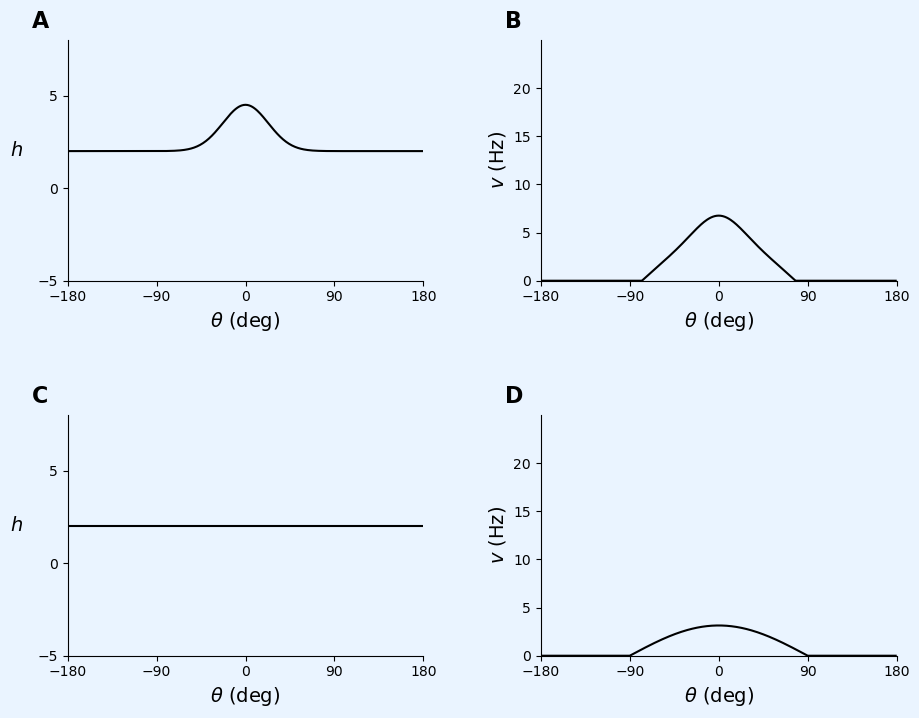

In [8]:
%run tutorials/7.14.py

### 7.4.2.7 Maximum Likelihood & Network Recoding(最大似然性, 网络重编码)

- recall: Maximum Likelihood Decoding
  - $N$ 个神经元调制曲线 $f_{i}(s)$ 已知
  - 在时间 $t\in [0, T]$ 观察到 $N$ 个神经元放电活动 $\vec{r} = (r_{1}, r_{2}, \cdots, r_{N})$
  - 由于噪声, 神经元放电概率为 Poisson 分布, 则给定刺激 $s$, 观察到 $\vec{r}$ 的概率为 $\begin{aligned}P(\vec{r}|s) = \prod_{i=1}^{N}\frac{[f_{i}(s)T]^{r_{i}}}{r_{i}!}e^{-f_{i}(s)T} \end{aligned}$
  - 寻找 $s = \hat{s}$ 使得 $P(\vec{r}|s)$ 最大. 对数导数 $\begin{aligned}\frac{\partial \ln{P(\vec{r}|s)}}{\partial s} = \sum_{i=1}^{N}\left[\frac{r_{i}}{f_{i}(s)}f^{\prime}_{i}(s)-f_{i}^{\prime}(s)T\right] = 0\end{aligned}$. 
  - 假设 $f$ 均匀覆盖 $s$ 空间, 则总平均响应约为常数: $\begin{aligned}\sum_{i=1}^{N}f_{i}(s) = \mathrm{const.}\Rightarrow \sum_{i=1}^{N}f_{i}^{\prime}(s) = 0\end{aligned}$. 
  - 解得 $\hat{s}$ 约束为 $\begin{aligned}\sum_{i=1}^{N}r_{i}\frac{f_{i}^{\prime}(s)}{f_{i}(s)} = 0\end{aligned}$
- 循环网络: 大脑不需要计算导数, 而是利用网络结构特性做到同样的效果
  - 循环网络接收复杂输入 $h(\theta)$ 时, 也可产生特征性输出/响应 $v(\theta)$
  - 已知: $h(\theta)$ 改为均匀输入时, 之前的 $v(\theta)$ 的峰值位置 $\Theta$ 仍然维持
  - 特征性输出 $v(\theta)$ 的峰值位置 $\Theta$ 是对输入 $h(\theta)$ 的匹配结果, 可被解读为一种 Maximum Likelihood 解码. 
  - [Example]

    <img src="https://files.seeusercontent.com/2026/05/06/bf8B/20260506140335162.png" width="50%">

    - A: $N = 64$. $h(\theta)$ 噪声标准差 $\sigma = 0.25\,\mathrm{Hz}$. 向量解码输入 $h(\theta)$ 的标准差 $\sigma_{\Theta} = 4.5^{\circ}$. 稳态后均匀输入 $h(\theta) = 10$
    - B: 循环权重为 Gabor-like 函数 $\begin{aligned}W(\theta,\theta^{\prime}) = A\exp{\left[-\frac{(\theta-\theta^{\prime})^{2}}{2\sigma^{2}}\right]}\cos{[k(\theta-\theta^{\prime})]} - B\end{aligned}$. 使用向量解码输出 $v(\theta)$ 得到得 $\sigma_{\Theta} = 1.7^{\circ} \sim 0.88^{\circ}$, 接近 Cramer-Rao 下界.  

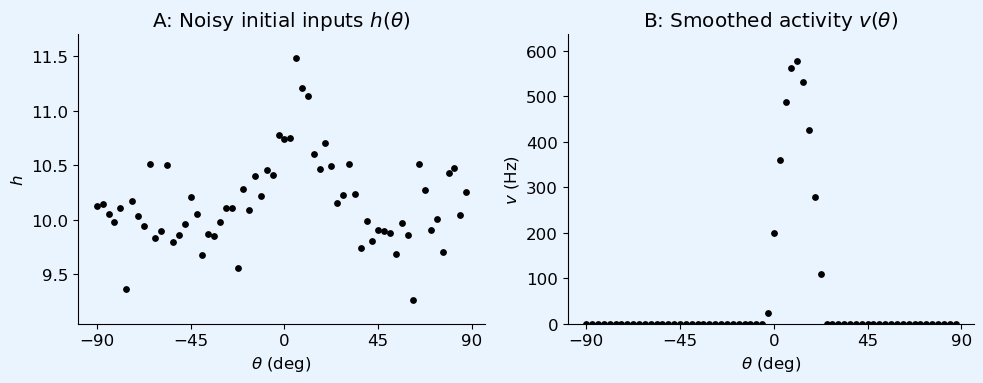

In [9]:
%run tutorials/7.15.py

## 7.4.3 Network Stability(网络稳定性)

不动点行为(fixed-point behavior): 网络对恒定输入 $h(t) = h$ 弛豫到稳态 $\begin{aligned}\left(\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = 0\right)\end{aligned}$

> recall: $\begin{aligned} \tau_{s}\frac{\mathrm{d}I_{s}}{\mathrm{d}t} = - I_{s} + \vec{w}\cdot\vec{u},\quad v = F(I_{s}) \end{aligned}$

延拓至循环网络, 有 Firing-rate model 动力学 $\begin{aligned}\tau_{s}\frac{\mathrm{d}\vec{I}}{\mathrm{d}t} = - \vec{I} + \vec{h} + \mathbb{M}\vec{F}(\vec{I})\end{aligned}$, 或分量形式 $\begin{aligned}\tau_{s}\frac{\mathrm{d}I_{a}}{\mathrm{d}t} = - I_{a} + h_{a} + \sum_{a^{\prime}=1}^{N_{v}}M_{aa^{\prime}}F(I_{a^{\prime}})\end{aligned}$. 假定 $F(\cdot)$ 单调递增($F^{\prime}>0$)

Cohen & Grossberg: 循环网络为对称阵时, 定义 Lyapunov 函数 $\begin{aligned}L(\vec{I}) = \sum_{a=1}^{N_{v}}\left[
    \int_{0}^{I_{a}}\mathrm{d}z_{a}\,z_{a}F^{\prime}(z_{a}) 
    - h_{a}F(I_{a}) 
    - \frac{1}{2}\sum_{a^{\prime}=1}^{N_{v}}F(I_{a})M_{aa^{\prime}}F(I_{a^{\prime}})\right]
\end{aligned}$

若 $\begin{aligned}\frac{\mathrm{d}\vec{I}}{\mathrm{d}t} \neq 0\end{aligned}$, 则 $\begin{aligned}\frac{\mathrm{d}\vec{I}}{\mathrm{d}t} < 0\end{aligned}$. 若 $L$ 有下界, 则 $\vec{I}$ 和 $\vec{v}$ 收敛至不动点. 




---

求导数 $\begin{aligned}\frac{\mathrm{d}L}{\mathrm{d}t}\end{aligned}$. 

- 第一项: $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}\int_{0}^{I_{a}}\mathrm{d}z_{a}\,z_{a}F^{\prime}(z_{a}) = I_{a}\,F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\end{aligned}$
- 第二项: $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}[-h_{a}F(I_{a})] = -h_{a}\,F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\end{aligned}$
- 第三项: $\begin{aligned}\frac{\mathrm{d}}{\mathrm{d}t}\left[-\frac{1}{2}\sum_{a^{\prime}=1}^{N_{v}}F(I_{a})M_{aa^{\prime}}F(I_{a^{\prime}})\right] = -\frac{1}{2}\sum_{a^{\prime}=1}^{N_{v}}\left[F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}M_{aa^{\prime}}F(I_{a^{\prime}}) + F(I_{a})M_{aa^{\prime}}F^{\prime}(I_{a^{\prime}})\frac{\mathrm{d}I_{a^{\prime}}}{\mathrm{d}t}\right] = -\sum_{a^{\prime}=1}^{N_{v}}F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\,M_{aa^{\prime}}F(I_{a^{\prime}})\end{aligned}$
- 求和: $\begin{aligned}\frac{\mathrm{d}L}{\mathrm{d}t} = \sum_{a=1}^{N_{v}}F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t} \left[I_{a} - h_{a} - \sum_{a^{\prime}=1}^{N_{v}}M_{aa^{\prime}}F(I_{a^{\prime}})\right]\end{aligned}$, 注意动力学 $\begin{aligned}-\tau_{s}\frac{\mathrm{d}I_{a}}{\mathrm{d}t} = I_{a} - h_{a} - \sum_{a^{\prime}=1}^{N_{v}}M_{aa^{\prime}}F(I_{a^{\prime}})\end{aligned}$, 替换得出结论
- 结论: $\begin{aligned}\frac{\mathrm{d}L}{\mathrm{d}t} = \sum_{a=1}^{N_{v}}F^{\prime}(I_{a})\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\left(-\tau_{s}\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\right) = -\tau_{s}\sum_{a=1}^{N_{v}}F^{\prime}(I_{a})\left(\frac{\mathrm{d}I_{a}}{\mathrm{d}t}\right)^2\leq 0\end{aligned}$

---

$F^{\prime} > 0$ 是一个计算方便的假设. 实际上, $F(x) = [x]_{+}$ 也满足不动点条件. (相当于 $I<0$ 的神经元暂时退出网络)





- 更一般的结论: 不动点要求 Lyapunov 函数有下界. 方法:
  - 使用饱和激活函数(saturating activation function, 如 sigmoid 函数): $I\to\infty, \exists\,\mathrm{sup}\,F(I)$
  - $\mathbb{M}$ 的本征值足够小

## 7.4.4 Associative Memory(联想记忆)

- 短期记忆/工作记忆
  - 通过持续活动保存信息
  - 数秒到数分钟级别
- 长期记忆
  - 通过突触强度的存储保存信息
  - 突触权重被修改, 持续活动作为发起回忆的信号, 从而生成特定输出模式(pattern) $\vec{v}$. 突触权重作为所有记忆模式(pattern)的长期存储库
  - 生物学基础
    - 海马体(hippocampus) 的 CA3 区
    - 部分前额叶皮质(prefrontal cortex)
  - 联想记忆: 通过部分输入存储模式, 来回忆完整模式(内容寻址 content-addressable); 不同于计算机的地址寻址(address-addressable)
    - [Example] 314159...
    - 循环权重 $\mathbb{M}$ 被设计, 从而拥有一组离散不动点, 每一个不动点对应记忆模式. 
    - 不动点的吸引域(basin of attraction): 使网络演化到该不动点的活动相空间. 


动力学: $\begin{aligned}\tau_{r}\frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = -\vec{v} + \vec{F}(\vec{h} + \mathbb{M}\vec{v})\end{aligned}$, 设 $\vec{h} = 0$. 

要求网络存储 $N_{\mathrm{mem}}$ 个记忆模式 $\vec{v}^{(m)}\,(m=1,2,\ldots,N_{\mathrm{mem}})$, 且初始状态 $\vec{v}(0)\approx \vec{v}^{(m)}$ 演化后收敛至 $\vec{v}^{(m)}$. 不动点方程 $\vec{v}^{(m)} = \vec{F}(\mathbb{M}\vec{v}^{(m)})$

简化: 不活跃神经元 $v^{(m)}_{i} = 0$, 活跃神经元 $v_{i}^{(m)} = c$. 设每个记忆模式有 $\alpha N_{v}$ 个活跃神经元和 $(1-\alpha)N_{v}$ 个不活跃神经元. 

> $\alpha$: 记忆模式的稀疏度(sparsity). $\alpha$ 减小则模式稀疏, 可存储更多模式, 而信息量更少 

构造 $\mathbb{K}$, 记忆模式 $\vec{v}^{(m)}$ 均是其本征矢且本征值相同: $\mathbb{K}\vec{v}^{(m)} = \lambda\vec{v}^{(m)}\,(\forall m)$. 

构造权重矩阵 $\begin{aligned}\mathbb{M} = \mathbb{K} - \frac{\vec{1}\vec{1}^{T}}{\alpha N_{v}}\end{aligned}$, 列向量 $\vec{1} = [1,1,\ldots,1]^{T}\in\mathbb{R}^{N_{v}}$, 第二项代表全局抑制. 

注意 $\begin{aligned}\mathbb{M}\vec{v}^{(m)} = \lambda\vec{v}^{(m)} - \frac{\vec{1}}{\alpha N_{v}}[\vec{1}^{T}\vec{v}^{(m)}] = \lambda\vec{v}^{(m)} - \frac{\vec{1}}{\alpha N_{v}} c\alpha N_{v} = \lambda\vec{v}^{(m)} - c\vec{1}\end{aligned}$. 

相当于活跃神经元输入 $\lambda c-c = (\lambda-1)c$, 不活跃神经元输入 $0-c = -c$. 对应不动点方程组 $\begin{aligned}\begin{cases}c = F[(\lambda-1)c]\\0 = F(-c)\end{cases}\end{aligned}$ 

- $c>0$. 对于 $F(x) = [x]_{+}$
  - $F(-c) = 0$ 恒成立. 
  - 若 $F^{\prime} > 0$, 则 $\lambda > 1$. 可以计算得到临界 $\lambda_{c} = 2$. 稍微偏离 $\lambda_{c}$ 则会发散或者衰减. 
  - 生物学条件: 
    - $\lambda > 1$, 以保证 $c(\lambda-1)>0$
    - $(\lambda-1)F^{\prime}(0) > 1$: 网络迅速逃离 $0$ 状态
    - $F(c(\lambda-1))$ 增长慢于 $c$ (饱和性 saturation), 避免发散



$\vec{v}^{(m)}$ 为矩阵 $\mathbb{K}$ 的 $N_{\mathrm{mem}}$ 度简并本征矢, 因此存在虚假(spurious)不动点 $\begin{aligned}\vec{v}_{s} = \sum_{m=1}^{N_{\mathrm{mem}}} c_{m}\vec{v}^{(m)}\end{aligned}$ 同样满足本征方程 $\mathbb{K}\vec{v}_{s} = \lambda\vec{v}_{s}$. 

网络非线性阻止 $\vec{v}_{s}$ 满足不动点方程 $\vec{v} = \vec{F}(\mathbb{M}\vec{v})$. 

> - 设想 $\begin{aligned}\sum_{m=1}^{N_{\mathrm{mem}}}c_{m} = 1\end{aligned}$ 使得输出仍然为 $c$. 
> - 然而, 存在非重叠区(如只在模式 1 活跃), 其输入仅为 $c_{1}c$. 而要求饱和响应(非线性), 无法做到 $c_{1}c = F(c_{1}c)$. 
> - 因此 $\begin{aligned}\vec{v}_{s} = \sum_{m=1}^{N_{\mathrm{mem}}} c_{m}\vec{v}^{(m)}\end{aligned}$ 不满足不动点方程

如何构造 $\mathbb{K}$? 

- 模式内积
  - 某神经元 $i$ 在记忆模式 $\vec{v}^{(m)}$ 激活的概率为 $P(\vec{v}_{i}^{(m)}=c) = \alpha$. $\vec{v}^{(m)}\cdot\vec{v}^{(m)} = N_{v}\alpha c^{2}$. 
  - 神经元在 $m, n$ 模式都激活的概率为 $\alpha^{2}$, 对 $m\neq n$ 有 $\vec{v}^{(m)}\cdot\vec{v}^{(n)} \approx N_{v}\alpha^{2}c^{2}$
- 构造矢量 $\vec{v}^{(n)} - \alpha c\vec{1}$, 注意 $\vec{v}^{(m)}\cdot\vec{1} = N_{v}\alpha c$
  - $m=n$: $\vec{v}^{(m)}\cdot(\vec{v}^{(n)}-\alpha c\vec{1}) = N_{v}\alpha c^{2} - \alpha c N_{v}\alpha c = N_{v}\,\alpha(1-\alpha)\,c^{2}$
  - $m\neq n$: $\vec{v}^{(m)}\cdot(\vec{v}^{(n)}-\alpha c\vec{1}) = N_{v}\alpha^{2}c^{2} - \alpha c N_{v}\alpha c = 0$
  - 归一化矢量: 
    - 矩阵元形式 $\begin{aligned}\vec{v}^{(m)}\cdot \frac{\vec{v}^{(n)}-\alpha c\vec{1}}{N_{v}\,\alpha(1-\alpha)\,c^{2}} = \delta_{mn}\end{aligned}$, 或严格横竖向量形式 $\begin{aligned}\frac{(\vec{v}^{(n)}-\alpha c\vec{1})^{T}}{N_{v}\,\alpha(1-\alpha)\,c^{2}}\vec{v}^{(m)} = \delta_{mn} \end{aligned}$
    - 矩阵形式 $\begin{aligned} \mathbb{I} = \sum_{n=1}^{N_{\mathrm{mem}}}\vec{v}^{(m)}\frac{(\vec{v}^{(n)}-\alpha c\vec{1})^{T}}{N_{v}\,\alpha(1-\alpha)\,c^{2}}\end{aligned}$ (只需要单次求和, 思考为什么)
- $\begin{aligned}\mathbb{K} = \lambda\mathbb{I} = \frac{\lambda}{N_{v}\,\alpha(1-\alpha)\,c^{2}} \sum_{n=1}^{N_{\mathrm{mem}}}\vec{v}^{(m)}(\vec{v}^{(n)}-\alpha c\vec{1})^{T}\end{aligned}$, 检验本征方程 $\begin{aligned}\mathbb{K}\vec{v}^{(m)} = \lambda \sum_{n=1}^{N_{\mathrm{mem}}}\vec{v}^{(m)}\frac{(\vec{v}^{(n)}-\alpha c\vec{1})^{T}}{N_{v}\,\alpha(1-\alpha)\,c^{2}} \vec{v}^{(m)} = \lambda \sum_{n=1}^{N_{\mathrm{mem}}}\vec{v}^{(m)}\delta_{mn} = \lambda \vec{v}^{(m)}\end{aligned}$, 成立
- 构造对称循环权重矩阵 $\mathbb{M}$ (Lyapunov 函数要求)
  - 全局抑制项 $\begin{aligned}-\frac{\vec{1}\vec{1}^{T}}{\alpha N_{v}} \end{aligned}$ 自动对称, 只需构造对称 $\mathbb{K}$. 令 $\begin{aligned}\mathbb{K} = \frac{\lambda}{N_{v}\,\alpha(1-\alpha)\,c^{2}} \sum_{n=1}^{N_{\mathrm{mem}}}(\vec{v}^{(n)}-\alpha c\vec{1})(\vec{v}^{(n)}-\alpha c\vec{1})^{T}\end{aligned}$
  - $\begin{aligned}\mathbb{M} = \frac{\lambda}{N_{v}\,\alpha(1-\alpha)\,c^{2}} \sum_{n=1}^{N_{\mathrm{mem}}}(\vec{v}^{(n)}-\alpha c\vec{1})(\vec{v}^{(n)}-\alpha c\vec{1})^{T} - \frac{\vec{1}\vec{1}^{T}}{\alpha N_{v}} \end{aligned}$
  - 重新计算不动点条件 $\mathbb{M}\vec{v}^{(m)}$
    - 第一项: $\begin{aligned} \lambda \sum_{n=1}^{N_{\mathrm{mem}}}(\vec{v}^{(n)}-\alpha c\vec{1}) \frac{(\vec{v}^{(n)}-\alpha c\vec{1})^{T}}{N_{v}\,\alpha(1-\alpha)\,c^{2}}\vec{v}^{(m)} = \lambda\sum_{n=1}^{N_{\mathrm{mem}}}(\vec{v}^{(n)}-\alpha c\vec{1})\delta_{mn} = \lambda(\vec{v}^{(m)} - \alpha c\vec{1})\end{aligned}$
    - 第二项: $\begin{aligned}-\frac{\vec{1}\vec{1}^{T}}{\alpha N_{v}}\vec{v}^{(m)} = -\frac{\vec{1}}{\alpha N_{v}}(\vec{1}^{T}\vec{v}^{(m)}) = -\frac{\vec{1}}{\alpha N_{v}} N_{v}\alpha c = -c\vec{1}\end{aligned}$
    - $\mathbb{M}\vec{v}^{(m)} = \lambda(\vec{v}^{(m)} - \alpha c\vec{1}) - c\vec{1} = \lambda\vec{v}^{(m)} - c(1+\alpha\lambda)\vec{1}$
    - 不活跃神经元: $h = \lambda\cdot 0 - c(1+\alpha\lambda)\cdot 1 = -c(1+\alpha\lambda)$, 则不动点条件 $0 = F[-c(1+\alpha\lambda)]$
    - 活跃神经元: $h = \lambda\cdot c - c(1+\alpha\lambda)\cdot 1 = c(\lambda - 1 - \alpha\lambda) = c(\lambda(1-\alpha) - 1)$, 则不动点条件 $c = F[c(\lambda(1-\alpha) - 1)]$
  - 不动点方程组 $\begin{aligned}\begin{cases}0 = F[-c(1+\alpha\lambda)]\\c = F[c(\lambda - 1 -\alpha\lambda)]\end{cases}\end{aligned}$
- Hebb's rule / 协方差规则(covariance rule): Fire together, wire together. 
  - 对神经元 $i,j$ 的连接 $\begin{aligned}M_{ij} = \frac{\lambda}{N_{v}\,\alpha(1-\alpha)\,c^{2}} \sum_{n=1}^{N_{\mathrm{mem}}}(v^{(n)}_{i}-\alpha c)(v_{j}^{(n)}-\alpha c)^{T} - \frac{1}{\alpha N_{v}}\end{aligned}$
  - 同时激活 ($v_{i}^{(n)} = v_{j}^{(n)} = c$): $(c-\alpha c)(c-\alpha c) = (1-\alpha)^{2}c^{2}>0$
  - 同时静息 ($v_{i}^{(n)} = v_{j}^{(n)} = 0$): $(0-\alpha c)(0-\alpha c) = \alpha^{2}c^{2}>0$
  - 一个活跃, 一个静息($v_{i}^{(n)} = c$, $v_{j}^{(n)} = 0$): $(c-\alpha c)(0-\alpha c) = -\alpha (1-\alpha)c^{2} < 0$
- 构造的 $\mathbb{M}$ 并非最优选择, 只是近似满足存储条件, 回忆会有误差/ $N_{\mathrm{mem}}$ 较小
- 结论: 大网络可存储多模式, 特别是稀疏 ($\alpha\to 0$) 且容忍回忆错误. 

- 记忆模式数量 $N_{\mathrm{mem}}$
  - 和神经元数 $N_{v}$ 同量级
  - $\begin{aligned}N_{\mathrm{mem}} \propto -\frac{1}{\alpha\log{\alpha}}\end{aligned}$
  - 信息总量 $\propto N_{v}^{2}$ (即突触数量)
  
<img src="https://files.seeusercontent.com/2026/05/07/oO5r/20260507202651983.png" width="50%">

- Setup
  - $\begin{aligned}N_{v} = 50,\,\alpha = 0.25,\,\lambda = 1.25,\,F(I) = 150 \left[\tanh{\left(\frac{I+20}{150}\right)}\right]_{+}\end{aligned}$
- A: 在被回忆模式 $m$ 中, 代表性神经元 $i,j$ 的放电率活动.
  - 上神经元 $v^{(m)}_{i}$ 活跃. 趋于一未饱和稳态值
  - 下神经元 $v^{(m)}_{j}$ 静息. 趋于 0
- B: 回忆模式 $m$, $\vec{v}^{(m)}$ 中仅 18-31 号神经元非 0. 网络初态 $\vec{v}(0)$ 随机但与 $\vec{v}^{(m)}$ 相似. 稳态 $\vec{v}_{\infty} = \vec{v}^{(m)}$
- C: 回忆模式 $n$, $\vec{v}^{(n)}$ 中仅 $i,i+4,i+8\cdots$ 神经元非 0. 网络初态 $\vec{v}(0)$ 随机但与 $\vec{v}^{(n)}$ 相似. 稳态 $\vec{v}_{\infty} = \vec{v}^{(n)}$

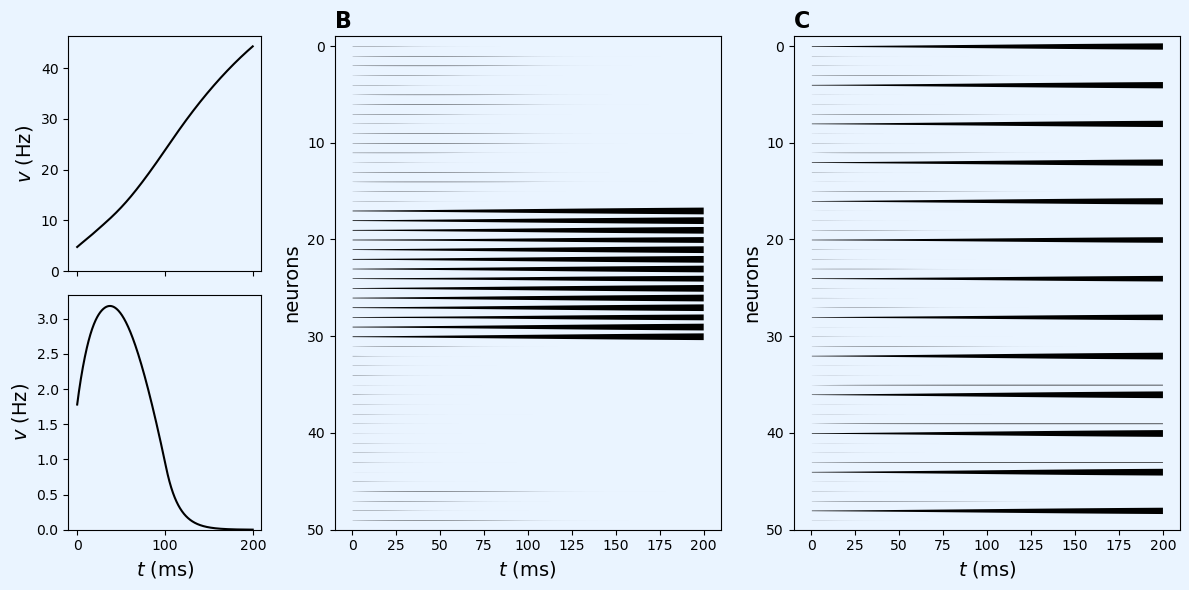

In [16]:
%run tutorials/7.16.py